In [1]:
%load_ext autoreload
%autoreload 2
import os
import sys

In [2]:
import json
import pandas as pd
import requests
from tqdm import tqdm
import time
import duckdb
import matplotlib.pyplot as plt

from dotenv import load_dotenv
load_dotenv()
REPO = os.getenv("REPO_PATH")
sys.path.append(os.path.join(REPO, 'src'))
import validation_utils as val 

from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from ragas import SingleTurnSample 
from ragas.metrics import ResponseRelevancy, Faithfulness, AspectCritic, FactualCorrectness, BleuScore, RougeScore, SemanticSimilarity
from ragas.metrics._string import NonLLMStringSimilarity, DistanceMeasure
from ragas.dataset_schema import SingleTurnSample
from ragas.metrics import RubricsScore

from openai import OpenAI
from ragas.llms import llm_factory
from openai import AsyncOpenAI

import pangaeapy.pandataset as pds

In [3]:
client = AsyncOpenAI(
    api_key=os.getenv("SURF_API_KEY"),
    base_url=os.getenv("SURF_API_BASE"),
)

llm = LangchainLLMWrapper(
    ChatOpenAI(
        model="mistralai/Devstral-Small-2-24B-Instruct-2512",
        api_key=os.getenv("SURF_API_KEY"),
        base_url=os.getenv("SURF_API_BASE"),
        temperature=0,      # deterministic judging
        max_tokens=2048,    # headroom for structured output; too low truncates the JSON
    )
)

/var/folders/kh/y9z_055x6gq8gc74b6y16r1c0000gn/T/ipykernel_48569/2022125049.py:6: DeprecationWarning: LangchainLLMWrapper is deprecated and will be removed in a future version. Use llm_factory instead: from openai import OpenAI; from ragas.llms import llm_factory; llm = llm_factory('gpt-4o-mini', client=OpenAI(api_key='...'))
  llm = LangchainLLMWrapper(


In [8]:
folder_predictions = os.path.join(REPO, 'data/predictions')
list_pred_pangaea = [f for f in os.listdir(folder_predictions) if f.startswith('pangaea_')]

In [10]:
list_pred_pangaea = list_pred_pangaea[3:4] 

list_pred_pangaea

['pangaea_mistralai_Devstral-Small-2-24B-Instruct-2512']

In [11]:
df_metadata_annot = pd.read_csv(os.path.join(REPO, 'outputs/pangaea/sample_20260629_163144_filtered_top5_per_topic.csv'))
col_names = ['name', 'description', 'keywords']
df_scores = df_metadata_annot.copy()

In [12]:
def serialize_dataset(df) -> str:
    # schema + stats + a sample beats raw rows: the judge reasons about
    # structure, not a lucky/unlucky row draw
    schema = "\n".join(f"- {c} ({t})" for c, t in df.dtypes.items())
    sample = df.head(5).to_markdown(index=False)
    return f"Columns:\n{schema}\n\nSample rows:\n{sample}\n\nRow count: {len(df)}"

async def score_all_abstracts(llm, df_merge, col_names, verbose=0, normalise=True):
    grounding_rubrics = {
        "score1_description": "Makes claims that contradict the data or reference fields/values that do not exist in it.",
        "score2_description": "Several claims are unsupported by the data or appear invented.",
        "score3_description": "Mostly supportable, but contains at least one unsupported or speculative claim.",
        "score4_description": "Every claim is supportable from the data; some claims are vague or generic.",
        "score5_description": "Every claim is directly supported by the data and is specific to it.",
    }
    scorer_faith = RubricsScore(rubrics=grounding_rubrics, llm=llm)
    scorer_sim = FactualCorrectness(llm=llm, mode="precision", atomicity="low")

    scores_faith = {}
    scores_sim = {}
    metadata_dict = {}
    order_metadata = ['full_abstract_pred', 'full_abstract_annot', 'data_ctx']
    for ii in tqdm(range(len(df_merge))):
        name = int(df_merge.iloc[ii]['id'])
        try:
            tmp = await score_faithfulness_abstract(scorer_faith, df_merge, ii, col_names, verbose)
            scores_faith[name] = tmp[0]
            if normalise:
                scores_faith[name] = (scores_faith[name] - 1) / 4   # normalise to 0–1
            metadata_dict[name] = {}
            for k, v in zip(order_metadata, tmp[1]):
                metadata_dict[name][k] = v

            tmp = await score_similarity_description(scorer_sim, df_merge, ii, col_names, verbose)
            scores_sim[name] = tmp
        except Exception as e:
            scores_faith[name] = None
            scores_sim[name] = None
            metadata_dict[name] = None
            print(f"row {name} failed: {e}")

    return scores_faith, scores_sim, metadata_dict

async def score_similarity_description(scorer, df_merge, ii, col_names, verbose=0):
    sample = SingleTurnSample(
        response=df_merge.iloc[ii]["description_pred"],
        reference=df_merge.iloc[ii]["description_annot"],
    )
    fc = await scorer.single_turn_ascore(sample)   # 0–1
    return fc

async def score_faithfulness_abstract(scorer, df_merge, ii, col_names, verbose=0):
    dataset_id = df_merge.iloc[ii]['id']
    df_tmp = pd.read_csv(REPO + f'outputs/pangaea/pangaea_datasets/{dataset_id}.csv')
    data_ctx = serialize_dataset(df_tmp)   # NOT df_merge (the annotations)
    if verbose:
        print(data_ctx)

    extracted_fields_annot = {col: df_merge.iloc[ii][f"{col}_annot"] for col in col_names}
    full_abstract_annot = '\n\n'.join(f'{k}: {v}' for k, v in extracted_fields_annot.items())
    
    extracted_fields_pred = {col: df_merge.iloc[ii][f"{col}_pred"] for col in col_names}
    full_abstract_pred = '\n\n'.join(f'{k}: {v}' for k, v in extracted_fields_pred.items())
    
    if verbose:
        print(full_abstract_annot)
        print(full_abstract_pred)

    sample = SingleTurnSample(
        user_input=(
            f"A model generated metadata for a dataset from the data alone.\n\n"
            f"DATASET:\n{data_ctx}\n\n"
            f"Judge only whether the TITLE, DESCRIPTION, and KEYWORDS below are grounded in this data — "
            f"whether its claims could be inferred from the data. Do not reward or "
            f"penalize style, completeness, or omissions."
        ),
        response=full_abstract_pred,
    )

    score = await scorer.single_turn_ascore(sample)
    return score, (full_abstract_pred, full_abstract_annot, data_ctx)



In [18]:
for fname in list_pred_pangaea:
    try:
        print(f"Processing predictions from: {fname}\n")
        
        df_metadata_inferred = val.get_metadata_files(os.path.join(folder_predictions, fname))
        df_merge, df_pred, df_annot, metadata_fields_present = val.precheck_validate(df_pred=df_metadata_inferred, df_annot=df_metadata_annot)
        assert df_pred.model.nunique() == 1, "Multiple models found in predictions; expected only one."
        model_name = df_pred.model.unique()[0]
        if f'faith_{model_name}' in df_scores.columns:
            print(f"skipping {model_name} (already scored)")
            continue
        scores_faith, scores_sim, metadata_dict = await score_all_abstracts(llm, df_merge, col_names)

        df_scores[f'faith_{model_name}'] = df_scores.id.map(scores_faith)
        df_scores[f'sim_{model_name}'] = df_scores.id.map(scores_sim)
        df_scores.to_csv(REPO + 'outputs/pangaea/df_scores_checkpoint.csv', index=False)  # persist per model
    except Exception as e:
        print(f"{fname} failed: {e}")
        continue

Processing predictions from: pangaea_mistralai_Devstral-Small-2-24B-Instruct-2512

Dropping columns from df_pred: ['license', 'spatial', 'spatialCoverage', 'temporal', 'temporalCoverage', 'fileset', 'recordset']


100%|██████████| 75/75 [15:58<00:00, 12.78s/it]


In [19]:
df_scores

,name,description,keywords,license,n_rows,n_columns,topic,doi,id,n_elements,...,faith_llama3_70B,sim_llama3_70B,faith_mistralai_Mistral-Small-3.2-24B-Instruct-2506,sim_mistralai_Mistral-Small-3.2-24B-Instruct-2506,faith_Qwen_3.6_35B,sim_Qwen_3.6_35B,faith_Qwen3.5-122B,sim_Qwen3.5-122B,faith_mistralai_Devstral-Small-2-24B-Instruct-2512,sim_mistralai_Devstral-Small-2-24B-Instruct-2512
0,A regional pCO2 climatology of the Baltic Sea,Based on direct surface pCO2 observation and a...,"['Baltic Sea', 'climatology', 'CO2']",Creative Commons Attribution 4.0 International,2,4,Lithosphere,doi:10.1594/PANGAEA.961119,961119,8,...,1.00,0.40,0.0,0.00,1.0,0.33,1.0,0.40,1.00,0.00
1,Underwater video recordings during mesopelagic...,During three cruises in the Mid Atlantic Ridge...,"['mesopelagic fish', 'mesopelagic invertebrates']",Creative Commons Attribution 4.0 International,2,7,Fisheries,doi:10.1594/PANGAEA.931902,931902,14,...,0.75,0.00,0.0,0.00,1.0,0.00,1.0,0.00,1.00,0.33
2,Involving local communities for effective citi...,These three datasets are related to the analys...,"['bushmeat', 'Citizen science', 'community-bas...",Creative Commons Attribution 4.0 International,3,5,Lakes & Rivers,doi:10.1594/PANGAEA.906209,906209,15,...,0.75,0.50,0.0,0.00,1.0,0.20,0.5,0.00,1.00,0.17
3,Raw data from Pure-rotational and Vibro-rotati...,The data correspond to measurements along a ve...,"['Experiment', 'extinction retrieval', 'pure-r...",Creative Commons Attribution 4.0 International,2,8,Human Dimensions,doi:10.1594/PANGAEA.931282,931282,16,...,1.00,0.25,0.0,0.00,1.0,0.00,1.0,0.27,1.00,0.00
4,"Ground Temperature Map, 2000-2017, Antarctic",The product provides modeled mean annual groun...,"['Antarctic', 'Cryosphere', 'ground temperatur...",Creative Commons Attribution 4.0 International,4,5,Cryosphere,doi:10.1594/PANGAEA.902576,902576,20,...,1.00,0.80,0.0,0.00,1.0,0.57,1.0,0.33,1.00,0.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,Daily meteorological data from automatic weath...,Presented dataset contains meteorological data...,"['automatic weather station', 'meteorology of ...",Creative Commons Attribution 4.0 International,2191,17,Atmosphere,doi:10.1594/PANGAEA.969067,969067,37247,...,1.00,1.00,1.0,0.87,1.0,0.83,1.0,0.86,1.00,0.86
71,A compilation of published pyrite sulfur isoto...,This dataset contains a compilation of the sul...,"['AGE', 'Depth', 'Lithology', 'Methane', 'pyri...",Creative Commons Attribution 4.0 International,3754,20,Geophysics,doi:10.1594/PANGAEA.972993,972993,75080,...,1.00,1.00,1.0,0.67,1.0,0.60,1.0,0.40,0.75,0.25
72,Continuous surface water vapour isotope monito...,This dataset presents the first fully continuo...,"['Antarctica', 'Continuous isotope monitoring'...",Creative Commons Attribution 4.0 International,17133,18,Atmosphere,doi:10.1594/PANGAEA.939047,939047,308394,...,1.00,0.60,1.0,0.50,1.0,0.50,1.0,0.25,1.00,0.17
73,Aerosol size distribution between 90 and 5000 ...,The aerosol size distribution between 90 and 5...,"['aerosol', 'Antarctica', 'size distribution',...",Creative Commons Attribution 4.0 International,8518,72,Atmosphere,doi:10.1594/PANGAEA.913861,913861,613296,...,1.00,0.40,0.0,0.00,1.0,0.50,1.0,0.33,1.00,0.37


In [36]:
df_scores = pd.read_csv(REPO + 'outputs/pangaea/df_scores_pangaea_descriptive.csv')

In [37]:
df_scores[df_scores.id.isin([908459, 899705, 897882])]

,name,description,keywords,license,n_rows,n_columns,topic,doi,id,n_elements,...,faith_llama3_70B,sim_llama3_70B,faith_mistralai_Mistral-Small-3.2-24B-Instruct-2506,sim_mistralai_Mistral-Small-3.2-24B-Instruct-2506,faith_Qwen_3.6_35B,sim_Qwen_3.6_35B,faith_Qwen3.5-122B,sim_Qwen3.5-122B,faith_mistralai_Devstral-Small-2-24B-Instruct-2512,sim_mistralai_Devstral-Small-2-24B-Instruct-2512
7,Estimated changes in anthropogenic emissions f...,Estimated changes in anthropogenic emissions o...,"['Asia-Pacific', 'EDGAR', 'Emissions']",Creative Commons Attribution 4.0 International,12,4,Ecology,doi:10.1594/PANGAEA.899705,899705,48,...,1.0,0.0,0.0,0.0,1.0,0.00,1.0,0.00,1.0,0.00
45,Seawater carbonate chemistry and shell microst...,Ocean acidification (OA) is well-known for imp...,"['Animalia', 'Benthic animals', 'Benthos', 'Bo...",Creative Commons Attribution 4.0 International,27,43,Biosphere,doi:10.1594/PANGAEA.908459,908459,1161,...,1.0,0.0,0.0,0.0,1.0,0.60,1.0,0.43,1.0,0.50
55,Data on spawning energetics and otolith microc...,"In marine fish, stock complexity confers resil...","['calorific value', 'Clupeidae', 'inverse estu...",Creative Commons Attribution 4.0 International,101,20,Fisheries,doi:10.1594/PANGAEA.897882,897882,2020,...,1.0,1.0,0.0,0.0,0.0,0.33,1.0,0.57,1.0,0.83


/var/folders/kh/y9z_055x6gq8gc74b6y16r1c0000gn/T/ipykernel_48569/3201072828.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[iplot].set_xticklabels(model_names, rotation=45, ha='right')
/var/folders/kh/y9z_055x6gq8gc74b6y16r1c0000gn/T/ipykernel_48569/3201072828.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[iplot].set_xticklabels(model_names, rotation=45, ha='right')


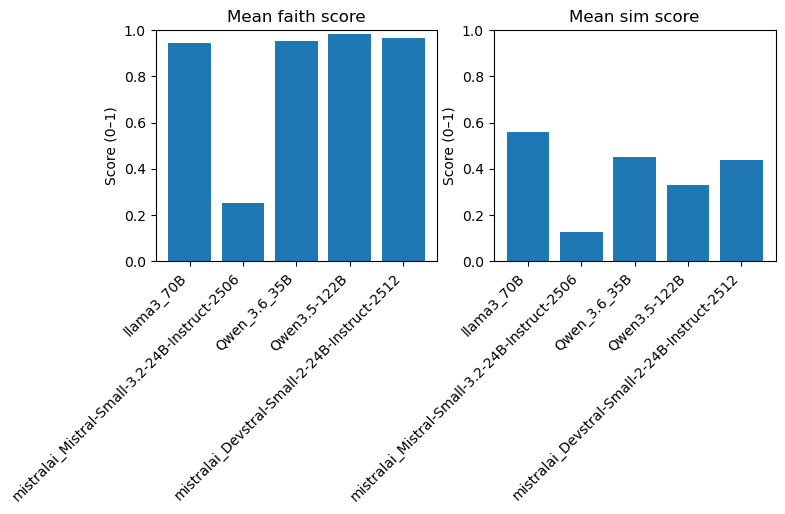

In [38]:
cols_metrics = [c for c in df_scores.columns if c.startswith('faith_') or c.startswith('sim_')]

model_names = ['_'.join(c.split('_')[1:]) for c in cols_metrics if c.startswith('faith_')]

fig, ax = plt.subplots(1, 2, figsize=(8, 3))
import numpy as np
for iplot, metric in enumerate(['faith', 'sim']):
    means = [df_scores[f'{metric}_{m}'].mean() for m in model_names]
    ax[iplot].bar(model_names, means)
    ax[iplot].set_title(f'Mean {metric} score')
    ax[iplot].set_ylim(0, 1)
    ax[iplot].set_ylabel('Score (0–1)')
    ax[iplot].set_xticklabels(model_names, rotation=45, ha='right')

In [33]:
cols_metrics = [c for c in df_scores.columns if c.startswith('faith_') or c.startswith('sim_')]
model_names = ['_'.join(c.split('_')[1:]) for c in cols_metrics if c.startswith('faith_')]

df_results_pan = {}

for metric in ['faith', 'sim']:
    tmp_mean = [(100 * df_scores[f'{metric}_{m}'].mean()).round(1) for m in model_names]
    tmp_std = [np.round(100 * df_scores[f'{metric}_{m}'].std(), 1) for m in model_names]
    tmp_sem = [np.round(100 * df_scores[f'{metric}_{m}'].sem(), 1) for m in model_names]
    tmp_score = [f'{m} ± {s}' for m, s in zip(tmp_mean, tmp_sem)]
    df_results_pan[metric] = tmp_score
df_results_pan['model'] = [x.replace('mistralai_Mistral-Small-3.2-24B-Instruct-2506', 'Mistral Small 3.2 24B').replace('mistralai_Devstral-Small-2-24B-Instruct-2512', 'Mistral Devstral 2 24B').replace('Qwen3.5-', 'Qwen 3.5 ').title().replace('_', ' ') for x in model_names]

df_results_pan = pd.DataFrame(df_results_pan)
df_results_pan = df_results_pan.rename(columns={'faith': 'Faithfulness [\%]', 'sim': 'Similarity [\%]', 'model': 'Model'})
df_results_pan = df_results_pan.set_index('Model')
df_results_pan = df_results_pan.sort_values(by=['Model'])
# df_results_pan
df_results_pan.to_latex(os.path.join(REPO, 'outputs/pangaea/df_results_pan.tex'), index=True, float_format="%.1f", 
                        caption="Data faithfulness and metadata similarity for the name, description and keywords metadata generated by different models on the PANGAEA dataset", label="tab:results_pan_semantic", position="h")

In [32]:
df_results_pan


,Faithfulness [\%],Similarity [\%]
Model,,
Llama3 70B,94.7 ± 1.7,56.0 ± 3.4
Mistral Devstral 2 24B,96.7 ± 1.5,43.9 ± 3.1
Mistral Small 3.2 24B,25.0 ± 4.7,12.7 ± 2.7
Qwen 3.5 122B,98.3 ± 1.0,33.1 ± 2.8
Qwen 3.6 35B,95.3 ± 2.1,45.1 ± 3.6


In [206]:
df_results_pan_extensive = df_scores.groupby('topic').agg({c: ['mean'] for c in cols_metrics}).round(3)#.to_csv(os.path.join(REPO, 'outputs/pangaea/df_results_pan_per_topic.csv'))
df_results_pan_extensive

,faith_llama3_70B,sim_llama3_70B,faith_mistralai_Mistral-Small-3.2-24B-Instruct-2506,sim_mistralai_Mistral-Small-3.2-24B-Instruct-2506,faith_Qwen_3.6_35B,sim_Qwen_3.6_35B,faith_Qwen3.5-122B,sim_Qwen3.5-122B
,mean,mean,mean,mean,mean,mean,mean,mean
topic,,,,,,,,
Agriculture,1.00,0.714,0.00,0.054,0.80,0.342,1.00,0.378
Atmosphere,0.95,0.600,0.60,0.302,1.00,0.632,1.00,0.368
Biological Classification,0.85,0.626,0.55,0.274,1.00,0.546,1.00,0.452
Biosphere,1.00,0.450,0.00,0.044,1.00,0.538,1.00,0.402
Chemistry,0.90,0.318,0.20,0.000,1.00,0.322,1.00,0.052
Cryosphere,1.00,0.704,0.40,0.246,1.00,0.628,1.00,0.352
Ecology,0.90,0.542,0.05,0.038,0.90,0.560,0.90,0.324
Fisheries,0.90,0.502,0.35,0.134,0.80,0.450,1.00,0.380


In [161]:
df_scores[df_scores.name =='Total organic carbon and total inorganic carbon content data of sediment core GeoB16310-3 from a coral mound in the Campeche Mound Province, Gulf of Mexico, MARIA S. MERIAN cruise MSM20/4']


,name,description,keywords,license,n_rows,n_columns,topic,doi,id,n_elements,citation_key,faith_llama3_70B,sim_llama3_70B,faith_mistralai_Mistral-Small-3.2-24B-Instruct-2506,sim_mistralai_Mistral-Small-3.2-24B-Instruct-2506,faith_Qwen_3.6_35B,sim_Qwen_3.6_35B,faith_Qwen3.5-122B,sim_Qwen3.5-122B
21,Total organic carbon and total inorganic carbo...,GeoB16310-3 is a gravity core taken from a cor...,"['Campeche Bank', 'cold-water coral reefs', 'c...",Creative Commons Attribution 4.0 International,23,8,Biosphere,doi:10.1594/PANGAEA.987068,987068,184,greiffenhagen2026toca,1.0,0.4,0.0,0.0,1.0,0.4,1.0,0.5


In [87]:
df_scores[df_scores.name =='Total organic carbon and total inorganic carbon content data of sediment core GeoB16310-3 from a coral mound in the Campeche Mound Province, Gulf of Mexico, MARIA S. MERIAN cruise MSM20/4']


def retrieve_metadata_by_id(df_scores, dataset_id, model='llama3_70B'):
    assert model in model_names, f"Model {model} not found in model_names: {model_names}"

    df_tmp = pd.read_csv(REPO + f'outputs/pangaea/pangaea_datasets/{dataset_id}.csv')
    data_context = serialize_dataset(df_tmp)

    row = df_scores[df_scores.id == dataset_id]

    path_pred = os.path.join(REPO, 'data/predictions', f'pangaea_{model}')
    tmp_files = [x for x in os.listdir(path_pred) if x.startswith(f'{dataset_id}')]
    path_pred = os.path.join(path_pred, tmp_files[0]) if tmp_files else None
    assert os.path.exists(path_pred), f"Prediction file not found: {path_pred}"

    with open(path_pred, 'r') as f:
        pred_data = json.load(f)

    print(model)
    return row, data_context, pred_data

tmp = retrieve_metadata_by_id(df_scores, 987068, model=model_names[2])  # pick the last model for demonstration

print(tmp[1])

print(tmp[0].keywords.values)

print(tmp[2])

Qwen_3.6_35B
Columns:
- Depth sed (float64)
- TOC (float64)
- TIC (float64)
- Event (object)
- Latitude (float64)
- Longitude (float64)
- Elevation (float64)
- Date/Time (object)

Sample rows:
|   Depth sed |   TOC |    TIC | Event       |   Latitude |   Longitude |   Elevation | Date/Time           |
|------------:|------:|-------:|:------------|-----------:|------------:|------------:|:--------------------|
|        0.1  | 0.603 |  9.997 | GeoB16310-3 |    23.8242 |    -87.1703 |        -573 | 2012-03-23 01:04:00 |
|        0.4  | 0.644 | 10.056 | GeoB16310-3 |    23.8242 |    -87.1703 |        -573 | 2012-03-23 01:04:00 |
|        0.75 | 0.58  | 10.02  | GeoB16310-3 |    23.8242 |    -87.1703 |        -573 | 2012-03-23 01:04:00 |
|        1.05 | 0.577 | 10.323 | GeoB16310-3 |    23.8242 |    -87.1703 |        -573 | 2012-03-23 01:04:00 |
|        1.35 | 0.626 | 10.274 | GeoB16310-3 |    23.8242 |    -87.1703 |        -573 | 2012-03-23 01:04:00 |

Row count: 23
["['Campeche Bank', 'c

Text(0.5, 1.1, 'Score distributions for model: Qwen3.5-122B\n')

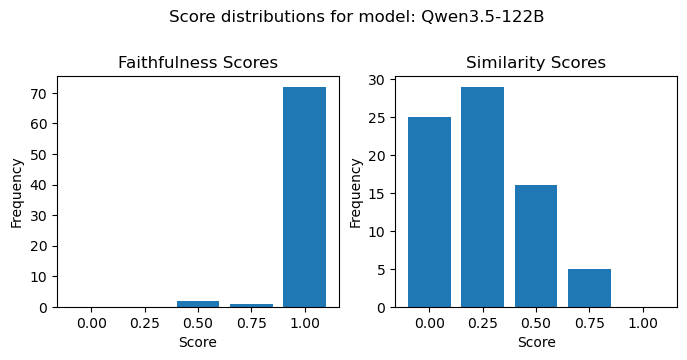

In [58]:
fig, ax = plt.subplots(1, 2, figsize=(8, 3))

model = model_names[-1]  # pick the first model for histogram plotting

ax[0].hist(df_scores[f'faith_{model}'].values, bins=5, range=(0, 1.25), align='left', rwidth=0.8)
ax[0].set_title('Faithfulness Scores')
ax[0].set_xlabel('Score')
ax[0].set_ylabel('Frequency')

ax[1].hist(df_scores[f'sim_{model}'].values, bins=5, range=(0, 1.25), align='left', rwidth=0.8)
ax[1].set_title('Similarity Scores')
ax[1].set_xlabel('Score')
ax[1].set_ylabel('Frequency')

fig.suptitle(f"Score distributions for model: {model}\n", y=1.1)

In [63]:
target_score = 1

ids_target_score = df_scores[df_scores[f'faith_{model}'] == target_score].id.values

In [66]:
df_scores[df_scores.id == ids_target_score[1]][[f'faith_{model}', f'sim_{model}']]

,faith_Qwen3.5-122B,sim_Qwen3.5-122B
1,1.0,0.0


# Spatiotemporal eval

In [419]:
folder_predictions = os.path.join(REPO, 'data/predictions')
list_pred_inat = [f for f in os.listdir(folder_predictions) if f.startswith('inat')]

folder_data = os.path.join(REPO, 'outputs/inaturalist/inaturalist_100_species_1000_obs')

In [42]:



def fix_dt(dt_str):
    '''Final format: YYYY-MM-DDTHH:MM:SS
    '''
    if not dt_str or not isinstance(dt_str, str):
        return None
    
    if dt_str[-1] == 'Z':
        dt_str = dt_str[:-1]

    if len(dt_str) == 10:
        dt_str = dt_str + 'T00:00:00'
    elif len(dt_str) == 16 and dt_str[10] == 'T' and dt_str[13] == ':':
        dt_str = dt_str + ':00'

    return dt_str

def eval_spat_temp(folder_pred, folder_data):
    base_cols = ['min_lon', 'max_lon', 'min_lat', 'max_lat', 'min_time', 'max_time']
    df_metadata = {
        x: []
        for x in ['id']
        + [f"{c}_annot" for c in base_cols]
        + [f"{c}_pred" for c in base_cols]
    }

    for f in os.listdir(folder_data):
        species_name = f.replace('.csv', '').replace('_', ' ')
        df_sel = pd.read_csv(os.path.join(folder_data, f))
        lon = df_sel['decimalLongitude']
        lat = df_sel['decimalLatitude']
        min_lon, max_lon = lon.min(), lon.max()
        min_lat, max_lat = lat.min(), lat.max()

        df_sel['eventDate_fixed'] = df_sel['eventDate'].map(fix_dt)
        df_sel['datetime'] = pd.to_datetime(df_sel['eventDate_fixed'], errors='coerce')
        assert df_sel['datetime'].isnull().sum() == 0, f"Some datetime values could not be parsed: {df_sel[df_sel['datetime'].isnull()]['eventDate'].tolist()}"
        min_time, max_time = df_sel['datetime'].min(), df_sel['datetime'].max()

        df_metadata['id'].append(species_name)
        df_metadata['min_lon_annot'].append(min_lon)
        df_metadata['max_lon_annot'].append(max_lon)
        df_metadata['min_lat_annot'].append(min_lat)
        df_metadata['max_lat_annot'].append(max_lat)
        df_metadata['min_time_annot'].append(min_time)
        df_metadata['max_time_annot'].append(max_time)

        df_pred = pd.read_json(os.path.join(folder_pred, f"{species_name.replace(' ', '_')}_inaturalist.json"), orient='records')
        df_metadata['min_lon_pred'].append(df_pred.loc['min_lon', 'spatialCoverage'])
        df_metadata['max_lon_pred'].append(df_pred.loc['max_lon', 'spatialCoverage'])
        df_metadata['min_lat_pred'].append(df_pred.loc['min_lat', 'spatialCoverage'])
        df_metadata['max_lat_pred'].append(df_pred.loc['max_lat', 'spatialCoverage'])
        if 'from' in df_pred.index:
            df_metadata['min_time_pred'].append(fix_dt(df_pred.loc['from', 'temporalCoverage']))
        else:
            df_metadata['min_time_pred'].append(None)
        if 'to' in df_pred.index:
            df_metadata['max_time_pred'].append(fix_dt(df_pred.loc['to', 'temporalCoverage']))
        else:
            df_metadata['max_time_pred'].append(None)

    df_metadata = pd.DataFrame(df_metadata)
    df_metadata['min_time_pred'] = pd.to_datetime(df_metadata['min_time_pred'], errors='coerce').dt.tz_localize(None)
    df_metadata['max_time_pred'] = pd.to_datetime(df_metadata['max_time_pred'], errors='coerce').dt.tz_localize(None)

    scores = {}
    for c in base_cols:
        scores[c] = float((df_metadata[f'{c}_pred'] == df_metadata[f'{c}_annot']).sum())

    scores['temp_average'] = float(np.mean([scores[c] for c in ['min_time', 'max_time']]))  
    scores['spat_average'] = float(np.mean([scores[c] for c in ['min_lon', 'max_lon', 'min_lat', 'max_lat']]))
    
    return df_metadata, scores



In [424]:

folder_data = os.path.join(REPO, 'outputs/inaturalist/inaturalist_100_species_1000_obs')
df_results_inat = {x: [] for x in ['model', 'temporalCoverage', 'spatialCoverage']}
dict_df_metadata = {}
for fname in list_pred_inat:
    model_name = fname.replace('inat_', '').replace('.json', '')
    folder_pred = os.path.join(folder_predictions, fname)
    df_metadata, scores = eval_spat_temp(folder_pred, folder_data)
    print(f"{model_name}: {scores}")
    dict_df_metadata[model_name] = df_metadata

    df_results_inat['model'].append(model_name)
    df_results_inat['temporalCoverage'].append(scores['temp_average'])
    df_results_inat['spatialCoverage'].append(scores['spat_average'])

df_results_inat = pd.DataFrame(df_results_inat) 
df_results_inat['spatialCoverage'] = df_results_inat['spatialCoverage'].round(1)
df_results_inat['temporalCoverage'] = df_results_inat['temporalCoverage'].round(1)
model_names_mapping = {'default-text-large': 'Llama3 70B', 'Qwen_Qwen3.6-35B-A3B-FP8': 'Qwen 3.6 35B', 'mistralai_Mistral-Small-3.2-24B-Instruct-2506': 'Mistral Small 3.2 24B', 
                       'Qwen_Qwen3.5-122B-A10B-NVFP4': 'Qwen 3.5 122B', 'mistralai_Devstral-Small-2-24B-Instruct-2512': 'Mistral Devstral 2 24B'}
# 'Llama3 70B', 'Mistral Small 3.2 24B', 'Qwen 3.5 122B', 'Qwen 3.6 35B'

df_results_inat['model'] = [model_names_mapping.get(x, x) for x in df_results_inat['model']]

df_results_inat = df_results_inat.rename(columns={'temporalCoverage': 'Temp.\ accuracy [\%]', 'spatialCoverage': 'Spat.\ accuracy [\%]', 'model': 'Model'})
df_results_inat = df_results_inat.set_index('Model')
df_results_inat = df_results_inat.sort_values(by=['Model'])

# df_results_inat.to_latex(os.path.join(REPO, 'outputs/inaturalist/df_results_inat.tex'), index=True, float_format="%.1f",
                        # caption="Temporal and spatial accuracy for the metadata generated by different models on the iNaturalist dataset.", label="tab:results_inat", position="h")

Qwen_Qwen3.5-122B-A10B-NVFP4: {'min_lon': 99.0, 'max_lon': 100.0, 'min_lat': 98.0, 'max_lat': 99.0, 'min_time': 76.0, 'max_time': 76.0, 'temp_average': 76.0, 'spat_average': 99.0}
default-text-large: {'min_lon': 99.0, 'max_lon': 99.0, 'min_lat': 98.0, 'max_lat': 99.0, 'min_time': 95.0, 'max_time': 67.0, 'temp_average': 81.0, 'spat_average': 98.75}
Qwen_Qwen3.6-35B-A3B-FP8: {'min_lon': 95.0, 'max_lon': 96.0, 'min_lat': 94.0, 'max_lat': 95.0, 'min_time': 87.0, 'max_time': 87.0, 'temp_average': 87.0, 'spat_average': 95.0}
mistralai_Devstral-Small-2-24B-Instruct-2512: {'min_lon': 99.0, 'max_lon': 100.0, 'min_lat': 98.0, 'max_lat': 99.0, 'min_time': 70.0, 'max_time': 69.0, 'temp_average': 69.5, 'spat_average': 99.0}


In [422]:
df_results_inat

,Temp.\ accuracy [\%],Spat.\ accuracy [\%]
Model,,
Llama3 70B,81.0,98.8
Mistral Devstral 2 24B,69.5,99.0
Qwen 3.5 122B,76.0,99.0
Qwen 3.6 35B,87.0,95.0


In [ ]:
from scipy.stats import hypergeom


def overlap_test(set_a, set_b, n_total):
    """
    Test whether two sets overlap more than chance.

    Under the null, B is a random subset of the N items, independent of A,
    so |A n B| ~ Hypergeometric(N, |A|, |B|). 

    Returns:
      p_greater : P(overlap >= observed)  -- small => MORE overlap than chance
      p_less    : P(overlap <= observed)  -- small => LESS overlap than chance
    """
    A, B = set(set_a), set(set_b)
    a, b = len(A), len(B)
    if max(a, b) > n_total:
        raise ValueError("set larger than n_total")

    k = len(A & B)
    rv = hypergeom(n_total, a, b)
    return {
        "observed": k,
        "expected": a * b / n_total,
        "p_greater": rv.sf(k - 1),   # P(X >= k)
        "p_less": rv.cdf(k),         # P(X <= k)
        "p_twotailed": 2 * min(rv.cdf(k), rv.sf(k - 1)),
        "jaccard": k / len(A | B) if A | B else float("nan"),
    }

inds_fail = {}
for model_name, df_metadata in dict_df_metadata.items():
    print(f"Model: {model_name}")

    inds_nonmatch_temp = np.where(np.logical_or(df_metadata['min_time_pred'] != df_metadata['min_time_annot'],
                                                df_metadata['max_time_pred'] != df_metadata['max_time_annot']))[0]
    
    inds_fail[model_name] = inds_nonmatch_temp

pvals = []
for m1 in list(dict_df_metadata.keys()):
    for m2 in list(dict_df_metadata.keys()):
        if m1 >= m2:
            continue
        print(f"Comparing {m1} vs {m2}")
        set_a = set(inds_fail[m1])
        set_b = set(inds_fail[m2])
        n_total = 100
        res = overlap_test(set_a, set_b, n_total)
        # print(f"  Overlap: res = {res}")
        pval = res['p_twotailed']
        pvals.append(float(pval))

print(min(pvals))

pvals

Model: Qwen_Qwen3.5-122B-A10B-NVFP4
Model: default-text-large
Model: Qwen_Qwen3.6-35B-A3B-FP8
Model: mistralai_Devstral-Small-2-24B-Instruct-2512
Comparing Qwen_Qwen3.5-122B-A10B-NVFP4 vs default-text-large
Comparing Qwen_Qwen3.5-122B-A10B-NVFP4 vs Qwen_Qwen3.6-35B-A3B-FP8
Comparing Qwen_Qwen3.5-122B-A10B-NVFP4 vs mistralai_Devstral-Small-2-24B-Instruct-2512
Comparing default-text-large vs mistralai_Devstral-Small-2-24B-Instruct-2512
Comparing Qwen_Qwen3.6-35B-A3B-FP8 vs default-text-large
Comparing Qwen_Qwen3.6-35B-A3B-FP8 vs mistralai_Devstral-Small-2-24B-Instruct-2512
0.10838206519862068


[1.153923942188878,
 0.10838206519862068,
 0.9622161020342028,
 0.7443964501491812,
 0.873647356078531,
 0.32627332870385006]

In [439]:
list_inds_fails = list(inds_fail.values())

set_a = set(list_inds_fails[0])
set_b = set(list_inds_fails[1])
set_c = set(list_inds_fails[2])
set_d = set(list_inds_fails[3])

print(set_a & set_b & set_c & set_d)

print(set_b & set_c & set_d)
print(set_a & set_c & set_d)
print(set_a & set_b & set_d)
print(set_a & set_b & set_c)


set()
set()
set()
{np.int64(45)}
{np.int64(35), np.int64(15)}


In [ ]:
cols_metrics = [c for c in df_scores.columns if c.endswith('average')]
model_names = list(df_scores['model'])

df_results_pan = {}

for metric in ['temporalCoverage', 'spatialCoverage']:
    df_results_pan[metric] = [(1 * df_scores[f'{metric}_{m}'].mean()).round(1) for m in model_names]
df_results_pan['model'] = [x.replace('mistralai_Mistral-Small-3.2-24B-Instruct-2506', 'Mistral Small 3.2 24B').replace('Qwen3.5-', 'Qwen 3.5 ').title().replace('_', ' ') for x in model_names]

df_results_pan = pd.DataFrame(df_results_pan)
df_results_pan = df_results_pan.rename(columns={'faith': 'Faithfulness [\%]', 'sim': 'Similarity [\%]', 'model': 'Model'})
df_results_pan = df_results_pan.set_index('Model')
df_results_pan = df_results_pan.sort_values(by=['Model'])
# df_results_pan
df_results_pan.to_latex(os.path.join(REPO, 'outputs/pangaea/df_results_pan.tex'), index=True, float_format="%.1f", 
                        caption="Data faithfulness and metadata similarity for the name, description and keywords metadata generated by different models on the PANGAEA dataset.", label="tab:results_pan_semantic", position="h")

min_lon 99
max_lon 99
min_lat 98
max_lat 99
min_time 95
max_time 67


In [124]:
(df_metadata.max_time_pred == df_metadata.max_time_annot).sum()

np.int64(67)

## Pangaea spatial/temporal

In [39]:
folder_predictions = os.path.join(REPO, 'data/predictions')
list_pred_inat = [f for f in os.listdir(folder_predictions) if f.startswith('pangaea-quant')]
DELAY = 0.2
# folder_data = os.path.join(REPO, 'outputs/inaturalist/inaturalist_100_species_1000_obs')
df_metadata_annot = pd.read_csv(os.path.join(REPO, 'outputs/pangaea/sample_20260629_163144_filtered_top5_per_topic.csv'))
list_temp_extent = []
list_spat_extent = []

for row in tqdm(df_metadata_annot.itertuples()):
    dataset_id = row.id
    ds = pds.PanDataSet(dataset_id)

    temp_extent = (ds.mintimeextent, ds.maxtimeextent)
    spat_extent = ds.geometryextent

    if temp_extent[0] is None or temp_extent[1] is None:
        temp_extent = None 
    if len(spat_extent) == 0:
        spat_extent = None

    list_temp_extent.append(temp_extent)
    list_spat_extent.append(spat_extent)

    time.sleep(DELAY)
    
df_metadata_annot['temp_extent'] = list_temp_extent
df_metadata_annot['spat_extent'] = list_spat_extent

5it [00:02,  1.79it/s]Could not create QC flag dataframe - https://doi.org/10.1594/PANGAEA.954529
75it [00:47,  1.58it/s]


In [40]:
print(f'{df_metadata_annot.temp_extent.isnull().sum()} datasets have no temporal extent. \n {df_metadata_annot.spat_extent.isnull().sum()} datasets have no spatial extent.')

14 datasets have no temporal extent. 
 7 datasets have no spatial extent.


In [48]:

from duckdb import df


def eval_spat_temp_pangaea(folder_pred, df_metadata_annot, output_av_score_only=False):
    assert os.path.exists(folder_pred), f"Prediction folder does not exist: {folder_pred}"
    base_cols = ['min_lon', 'max_lon', 'min_lat', 'max_lat', 'min_time', 'max_time']
    df_metadata = {
        x: []
        for x in ['id']
        + [f"{c}_annot" for c in base_cols]
        + [f"{c}_pred" for c in base_cols]
    }

    ds_temp_nonnan = []
    ds_spat_nonnan = []   

    ds_visited = set()  # Keep track of visited datasets to avoid duplicates
    for f in os.listdir(folder_pred):
        ds_name = int(f.split('_')[0])  
        assert ds_name not in ds_visited, f"Duplicate dataset {ds_name} found in predictions; skipping."
        ds_visited.add(ds_name)  # Add the dataset name to the visited set
        ind_ds = df_metadata_annot[df_metadata_annot.id == ds_name].index
        if len(ind_ds) == 0:
            print(f"Dataset {ds_name} not found in annotations; skipping.")
            continue
        assert len(ind_ds) == 1, f"Multiple entries found for dataset {ds_name} in annotations."

        df_metadata['id'].append(ds_name)
        spat_extent = df_metadata_annot.loc[ind_ds, 'spat_extent'].values[0]
        if spat_extent is not None:
            min_lat, max_lat = spat_extent['southBoundLatitude'], spat_extent['northBoundLatitude']
            min_lon, max_lon = spat_extent['westBoundLongitude'], spat_extent['eastBoundLongitude']
            ds_spat_nonnan.append(ds_name)
        else:
            min_lon, max_lon, min_lat, max_lat = None, None, None, None
        temp_extent = df_metadata_annot.loc[ind_ds, 'temp_extent'].values[0]
        if temp_extent is not None:
            min_time, max_time = temp_extent[0], temp_extent[1]
            ds_temp_nonnan.append(ds_name)
        else:
            min_time, max_time = None, None

        df_metadata['min_lon_annot'].append(min_lon)
        df_metadata['max_lon_annot'].append(max_lon)
        df_metadata['min_lat_annot'].append(min_lat)
        df_metadata['max_lat_annot'].append(max_lat)
        df_metadata['min_time_annot'].append(min_time)
        df_metadata['max_time_annot'].append(max_time)

        df_pred = pd.read_json(os.path.join(folder_pred, f), orient='records')
        # print(df_pred)
        if 'min_lon' in df_pred.index:
            df_metadata['min_lon_pred'].append(df_pred.loc['min_lon', 'spatialCoverage'])
            df_metadata['max_lon_pred'].append(df_pred.loc['max_lon', 'spatialCoverage'])
            df_metadata['min_lat_pred'].append(df_pred.loc['min_lat', 'spatialCoverage'])
            df_metadata['max_lat_pred'].append(df_pred.loc['max_lat', 'spatialCoverage'])
        else:
            df_metadata['min_lon_pred'].append(None)
            df_metadata['max_lon_pred'].append(None)
            df_metadata['min_lat_pred'].append(None)
            df_metadata['max_lat_pred'].append(None)
        
        if 'from' in df_pred.index:
            df_metadata['min_time_pred'].append(fix_dt(df_pred.loc['from', 'temporalCoverage']))
        else:
            df_metadata['min_time_pred'].append(None)
        if 'to' in df_pred.index:
            df_metadata['max_time_pred'].append(fix_dt(df_pred.loc['to', 'temporalCoverage']))
        else:
            df_metadata['max_time_pred'].append(None)

    ds_all = set(df_metadata_annot.id.values)
    ds_not_visited = ds_all - ds_visited
    print(f"Datasets not visited in predictions: {len(ds_not_visited)}")
    if ds_not_visited:
        for ds in ds_not_visited:
            df_metadata['min_lon_annot'].append(None)
            df_metadata['max_lon_annot'].append(None)
            df_metadata['min_lat_annot'].append(None)
            df_metadata['max_lat_annot'].append(None)
            df_metadata['min_time_annot'].append(None)
            df_metadata['max_time_annot'].append(None)
            df_metadata['min_lon_pred'].append(None)
            df_metadata['max_lon_pred'].append(None)
            df_metadata['min_lat_pred'].append(None)
            df_metadata['max_lat_pred'].append(None)
            df_metadata['min_time_pred'].append(None)
            df_metadata['max_time_pred'].append(None)
            df_metadata['id'].append(ds)
    ## Compute accuracy for true positives, i.e., only for datasets where the ground truth is available.
    ## Calculate precision and recall for the temporal and spatial coverage predictions.
    for k, v in df_metadata.items():
        if len(v) != len(df_metadata['id']):
            raise ValueError(f"Length mismatch for key '{k}': expected {len(df_metadata['id'])}, got {len(v)}")
    df_metadata = pd.DataFrame(df_metadata)
    # return df_metadata, ds_temp_nonnan, ds_spat_nonnan
    # df_metadata['min_time_pred'] = pd.to_datetime(df_metadata['min_time_pred'], errors='coerce').dt.tz_localize(None)
    df_metadata['min_time_pred'] = pd.to_datetime(df_metadata['min_time_pred'].apply(lambda x: x[:19] if x is not None else None), errors='coerce').dt.tz_localize(None)
    # df_metadata['max_time_pred'] = pd.to_datetime(df_metadata['max_time_pred'], errors='coerce').dt.tz_localize(None)
    df_metadata['max_time_pred'] = pd.to_datetime(df_metadata['max_time_pred'].apply(lambda x: x[:19] if x is not None else None), errors='coerce').dt.tz_localize(None)
    df_metadata['min_time_annot'] = pd.to_datetime(df_metadata['min_time_annot'], errors='coerce').dt.tz_localize(None)
    df_metadata['max_time_annot'] = pd.to_datetime(df_metadata['max_time_annot'], errors='coerce').dt.tz_localize(None)

    # df_metadata['min_time_pred'] = df_metadata['min_time_pred'].astype(object).where(df_metadata['min_time_pred'] == pd.NaT, np.nan)
    # df_metadata['max_time_pred'] = df_metadata['max_time_pred'].astype(object).where(df_metadata['max_time_pred'] == pd.NaT, np.nan)

    for c in ['min_lat', 'max_lat', 'min_lon', 'max_lon']:
        df_metadata[f'{c}_pred'] = pd.to_numeric(df_metadata[f'{c}_pred'], errors='coerce')
        df_metadata[f'{c}_annot'] = pd.to_numeric(df_metadata[f'{c}_annot'], errors='coerce')

    df_metadata = df_metadata.sort_values(by='id').reset_index(drop=True)

    scores = {}
    for c in base_cols:
        # scores[c] = float((df_metadata[f'{c}_pred'] == df_metadata[f'{c}_annot']).sum())
        inds_tp = pd.notna(df_metadata[f'{c}_annot']) & pd.notna(df_metadata[f'{c}_pred'])
        inds_fp = pd.isna(df_metadata[f'{c}_annot']) & pd.notna(df_metadata[f'{c}_pred'])
        inds_fn = pd.notna(df_metadata[f'{c}_annot']) & pd.isna(df_metadata[f'{c}_pred'])
        inds_tn = pd.isna(df_metadata[f'{c}_annot']) & pd.isna(df_metadata[f'{c}_pred'])


        if 'time' in c:
            scores[c + '_accuracy'] = float((df_metadata[f'{c}_pred'].dt.date[inds_tp] == df_metadata[f'{c}_annot'].dt.date[inds_tp]).sum())
        else:
            scores[c + '_accuracy'] = float(np.sum(np.isclose(df_metadata[f'{c}_pred'][inds_tp], df_metadata[f'{c}_annot'][inds_tp], equal_nan=True)))
        scores[c + '_precision'] = float(np.sum(inds_tp)) / float(np.sum(inds_tp) + np.sum(inds_fp)) if (np.sum(inds_tp) + np.sum(inds_fp)) > 0 else None
        scores[c + '_recall'] = float(np.sum(inds_tp)) / float(np.sum(inds_tp) + np.sum(inds_fn)) if (np.sum(inds_tp) + np.sum(inds_fn)) > 0 else None

    for m in ['accuracy', 'precision', 'recall']:
        scores[f'temp_{m}_average'] = float(np.mean([scores[c] for c in [f'min_time_{m}', f'max_time_{m}']]))  
        scores[f'spat_{m}_average'] = float(np.mean([scores[c] for c in [f'min_lon_{m}', f'max_lon_{m}', f'min_lat_{m}', f'max_lat_{m}']]))

    if output_av_score_only:
        scores = {k: v for k, v in scores.items() if k.endswith('_average')}

    return df_metadata, scores

folders_pred = [f for f in os.listdir(folder_predictions) if f.startswith('pangaea-quant') and not f.endswith('old')]

scores_all = {}
for folder_pred in folders_pred:
    tmp = eval_spat_temp_pangaea(os.path.join(folder_predictions, folder_pred), df_metadata_annot, output_av_score_only=True)
    # print(folder_pred, tmp[1])
    if len(scores_all) == 0:
        scores_all['model'] = [folder_pred.replace('pangaea-quant_', '')]
        for k, v in tmp[1].items():
            scores_all[k] = [v]
    else:
        scores_all['model'].append(folder_pred.replace('pangaea-quant_', ''))
        for k, v in tmp[1].items():
            scores_all[k].append(v)

df_scores_all = pd.DataFrame(scores_all)
## split columns in two groups: temporal and spatial coverage
cols_temp = [c for c in df_scores_all.columns if c.startswith('temp_')]
cols_spat = [c for c in df_scores_all.columns if c.startswith('spat_')]
for c in cols_temp + cols_spat:
    if 'precision' in c or 'recall' in c:
        df_scores_all[c] = df_scores_all[c] * 100
    df_scores_all[c] = df_scores_all[c].round(1)
## create 2 levels of column names: metric and type, sort by type (temporal/spatial) and then by metric (accuracy/precision/recall)
df_scores_all.columns = pd.MultiIndex.from_tuples([(c.split('_')[0], '_'.join(c.split('_')[1:])) for c in df_scores_all.columns])
df_scores_all = df_scores_all.sort_index(axis=1, level=[0, 1], ascending=[True, True])
df_scores_all = df_scores_all.rename(columns={'model': 'Model', 'spat': 'Spatial coverage', 'temp': 'Temporal coverage'}, level=0)
df_scores_all = df_scores_all.rename(columns={'accuracy_average': 'TP accuracy [\%]', 'precision_average': 'Precision [\%]', 'recall_average': 'Recall [\%]'}, level=1)
model_names_mapping = {'default-text-large': 'Llama3 70B', 'Qwen_Qwen3.6-35B-A3B-FP8': 'Qwen 3.6 35B', 'mistralai_Mistral-Small-3.2-24B-Instruct-2506': 'Mistral Small 3.2 24B', 
                       'Qwen_Qwen3.5-122B-A10B-NVFP4': 'Qwen 3.5 122B', 'mistralai_Devstral-Small-2-24B-Instruct-2512': 'Mistral Devstral 2 24B'}
df_scores_all[('Model', '')] = [model_names_mapping.get(x, x) for x in df_scores_all[('Model', '')]]
## sort rows by model name
df_scores_all = df_scores_all.sort_values(by=[('Model', '')]).reset_index(drop=True)
df_scores_all.to_latex(os.path.join(REPO, 'outputs/pangaea/df_results_pan_spat_temp.tex'), index=False, float_format="%.1f",
                        caption="Temporal and spatial accuracy for the metadata generated by different models on the PANGAEA dataset. True positive (TP) accuracy was computed as the fraction of exact matches, so no standard error is shown.", label="tab:results_pan_spat_temp", position="h")

df_scores_all
# tmp = eval_spat_temp_pangaea(os.path.join(folder_predictions, folders_pred[2]), df_metadata_annot)
# print(folders_pred[2], tmp[1])

Datasets not visited in predictions: 8
Datasets not visited in predictions: 8
Datasets not visited in predictions: 7
Datasets not visited in predictions: 9


Model Spatial coverage                             \
                          TP accuracy [\%] Precision [\%] Recall [\%]   
0              Llama3 70B             60.5          100.0       100.0   
1  Mistral Devstral 2 24B             59.5           98.5       100.0   
2           Qwen 3.5 122B             60.5          100.0       100.0   
3            Qwen 3.6 35B             60.5           97.1       100.0   

  Temporal coverage                             
   TP accuracy [\%] Precision [\%] Recall [\%]  
0              53.0           91.9        96.6  
1              51.5           90.6        98.3  
2              49.5           95.0        96.6  
3              53.0           86.4        96.6